<a href="https://colab.research.google.com/github/paulinamena/Integracion-de-datos-y-prospectiva/blob/main/Reto_5_Riesgo_Operacional_Fallas_Tecnologicasipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Caso de estudio - Evaluación del Riesgo Operacional en Canales Electrónicos**

**Contexto del Caso**
Como analistas de riesgos de una entidad financiera líder, han recibido la base de datos histórica de Eventos de Riesgo Tecnológico ocurridos en los canales electrónicos (App móvil, Sucursal Virtual, Cajeros). Su misión es transformar estos datos crudos en una herramienta de decisión gerencial que permita cuantificar la exposición económica y la eficacia de los controles actuales.

**Objetivos del Reto**
Utilizando la metodología de Riesgo Operacional, desarrollar los siguientes entregables:


•	Arquitectura de Matrices: Construir de manera integrada las matrices de:
- Frecuencia (Eventos): Conteo de ocurrencias.
- Severidad: Clasificación por niveles de magnitud del daño.
- Pérdidas Agregadas: Producto de frecuencia y severidad.
- Impacto y Gestión: Crear la matriz de impacto y gestión.

•	Estimación Cuantitativa:
- Calcular la Pérdida Esperada (PE).
- Estimar el Operational Value at Risk (OpVaR) a un nivel de confianza del 99,9%.
- Nota: Realizar el cálculo comparativo para dos escenarios: Pérdidas No Gestionadas (Riesgo Inherente) vs. Pérdidas Gestionadas (Riesgo Residual).

•	Herramienta de Auditoría (Filtro Dinámico):
- Crear un tablero o funcionalidad que permita seleccionar cualquier celda de la matriz de pérdidas y despliegue automáticamente el listado detallado y la descripción de los eventos que la componen.


##0. Carga de las librerias de trabajo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###0.2. funcion de clusterización para poderla reutilizar

In [2]:
def clusterizacion(Xi, semilla=42):
    rng = np.random.default_rng(semilla)
    XC = np.sort(rng.choice(Xi, size=5, replace=False))   # semillas ordenadas
    nc = np.zeros((len(Xi), 1))

    for k in range(len(Xi)):
        d = np.abs(XC - Xi[k])          # distancia a cada semilla
        nc[k] = np.argmin(d)
        nc2 = int(nc[k])
        XC[nc2] = (XC[nc2] + Xi[k]) / 2  # actualización K-Medoids

    return XC, nc

##1. Cargamos los archivos de trabajo

In [4]:
file_path = '/content/drive/MyDrive/Integración de datos/5. Riesgo Operacional FallasTecnológicas.xlsx'

XDB  = pd.read_excel(file_path, sheet_name='Fallas Tecnológicas', header=1)
XDB.columns = ['Fecha', 'Trans_Diarias', 'Valor_Transado', 'Trans_Fallidas',
                'Severidad_M', 'Descripcion']
XDB['Fecha'] = pd.to_datetime(XDB['Fecha'])

# Tabla de riesgos y costos de gestión
RIESGOS = pd.read_excel(file_path, sheet_name='Riesgos', header=1, index_col=0)
GESTION = pd.read_excel(file_path, sheet_name='Gestión', header=1, index_col=0)

# Vectores de trabajo
Xf  = np.array(XDB['Trans_Fallidas'])   # Frecuencia: transacciones fallidas
Xs  = np.array(XDB['Severidad_M'])      # Severidad: valor generado promedio (M USD)
LDA = Xf * Xs                           # Pérdida Agregada (LDA)

# Clusterización de cada dimensión
XCf,  ncf   = clusterizacion(Xf)
XCs,  ncs   = clusterizacion(Xs)
XClda, nclda = clusterizacion(LDA)

# Dataframe unificado
df = pd.DataFrame({
    'Fecha'       : XDB['Fecha'],
    'Descripcion' : XDB['Descripcion'],
    'Freq'        : Xf,
    'Nivel_F'     : ncf.flatten().astype(int),
    'Sev'         : Xs,
    'Nivel_S'     : ncs.flatten().astype(int),
    'LDA'         : LDA,
    'Nivel_LDA'   : nclda.flatten().astype(int),
})

print(f'Centros Frecuencia : {np.round(XCf, 2)}')
print(f'Centros Severidad  : {np.round(XCs, 4)}')
print(f'Centros LDA        : {np.round(XClda, 2)}')
df.head()

Centros Frecuencia : [1 4 3 6 9]
Centros Severidad  : [ 0.3739  1.1628  3.8091  7.255  12.9818]
Centros LDA        : [ 2.93  9.92 27.7  44.95 62.82]


/tmp/ipykernel_3934/1959422853.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nc2 = int(nc[k])


,Fecha,Descripcion,Freq,Nivel_F,Sev,Nivel_S,LDA,Nivel_LDA
0,2009-01-01,"Errores visuales menores, problemas de usabili...",1,0,0.5374,3,0.5374,0
1,2009-01-02,"Errores en la interfaz de usuario, fallas en f...",4,3,1.1978,4,4.7912,4
2,2009-01-03,"Errores visuales menores, problemas de usabili...",5,3,0.4269,2,2.1345,3
3,2009-01-04,"Errores en la interfaz de usuario, fallas en f...",6,4,1.0814,4,6.4884,4
4,2009-01-05,"Errores en la interfaz de usuario, fallas en f...",7,4,1.2105,4,8.4735,4


##2. Construcción de matrices de riesgo

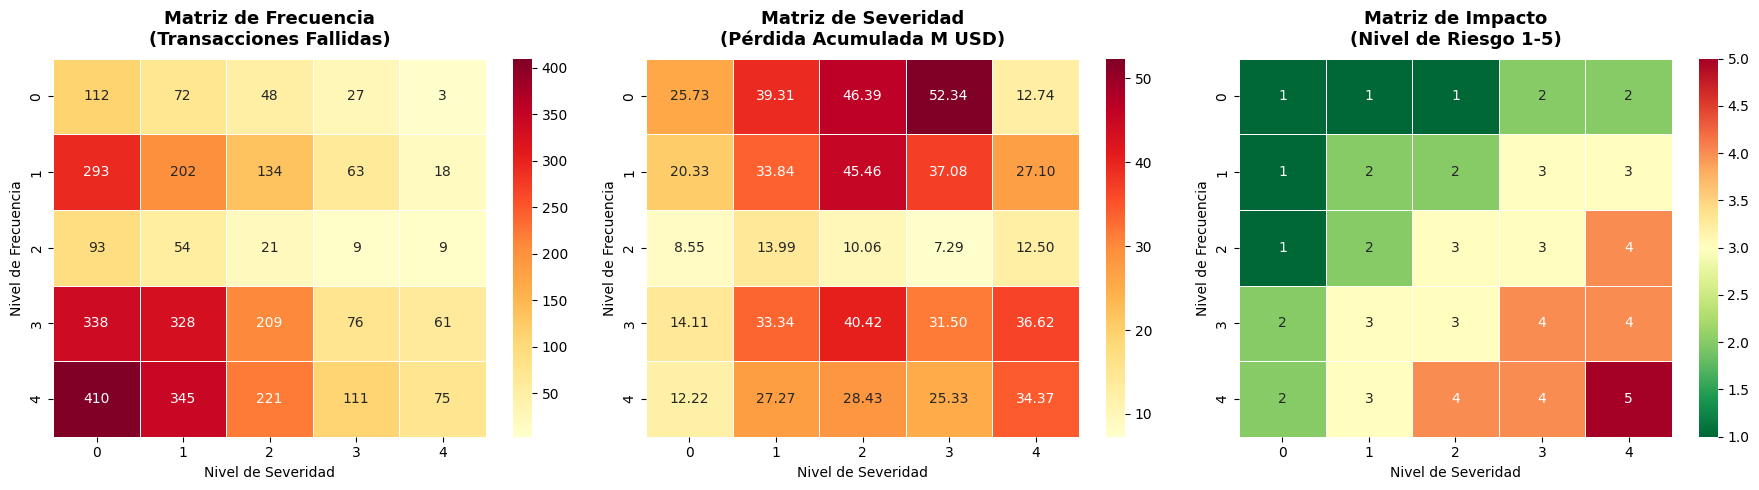

In [7]:
MEf = np.zeros((5, 5))   # Matriz de Frecuencia: conteo de transacciones fallidas
MEs = np.zeros((5, 5))   # Matriz de Severidad: acumulado de pérdida por celda

for k in range(len(Xf)):
    nf = df.iloc[k]['Nivel_F']   # fila    → nivel de frecuencia
    nc = df.iloc[k]['Nivel_S']   # columna → nivel de severidad
    MEf[nf, nc] += Xf[k]
    MEs[nf, nc] += Xs[k] / 2

# Matriz de Impacto (definida por expertos del negocio)
# Escala 1-5: 1=impacto bajo, 5=impacto catastrófico
MI = np.array([
    [1, 1, 1, 2, 2],
    [1, 2, 2, 3, 3],
    [1, 2, 3, 3, 4],
    [2, 3, 3, 4, 4],
    [2, 3, 4, 4, 5]
])

#Visualizaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def heatmap_matrix(ax, data, title, fmt='.1f', cmap='YlOrRd'):
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                linewidths=0.5, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Nivel de Severidad')
    ax.set_ylabel('Nivel de Frecuencia')

heatmap_matrix(axes[0], MEf, 'Matriz de Frecuencia\n(Transacciones Fallidas)', fmt='.0f')
heatmap_matrix(axes[1], MEs, 'Matriz de Severidad\n(Pérdida Acumulada M USD)', fmt='.2f')
heatmap_matrix(axes[2], MI,  'Matriz de Impacto\n(Nivel de Riesgo 1-5)',       fmt='.0f', cmap='RdYlGn_r')

plt.tight_layout()
plt.savefig('matrices_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()

Ingresar el nivel de gestión (1,2,3,4): 2


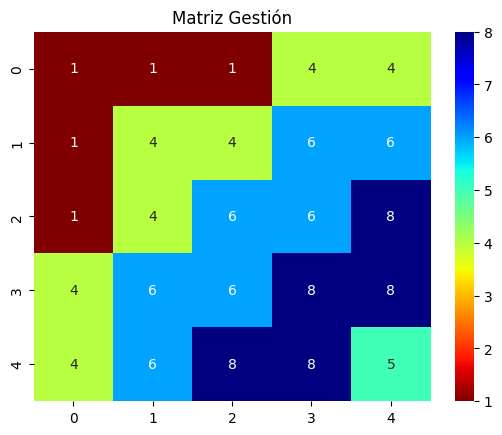

In [8]:
#Matriz de gestión - involucra recursos de la organización
NG=np.int32(input("Ingresar el nivel de gestión (1,2,3,4): "))
MG=np.copy(MI)

for i in range (5): #Si es mayor que 1 y menor que 5 incremente la gestion
  for j in range(5):
    if MG[i,j]>1 and MG[i,j]<5:
      MG[i,j]=MG[i,j]*NG

plt.figure()
sns.heatmap(MG, annot=True, fmt='.0f', cmap='jet_r') # Plot MG instead of MI
plt.title("Matriz Gestión")
plt.show()

##3. Estimación de las métricas estadisticas de Frecuencia e Impacto

In [10]:
#1. Perdida esperada por promedio simple
ps=np.mean(MEs)
print("El promedio simple de perdida es:", ps)

#2. Como no todos los contenedores tienen la mismas frecuencia, hay pocos contenedores que sufren perdidas extremas
pp=np.sum(MEf*MEs)/np.sum(MEf)
print("El promedio ponderado de severidad es:", pp)

#3. Se procede a determina la perdida ponderada teniendo igualmente la matriz de Impacto - Nivel de Riesgo
pnr=np.sum(MEf*MEs*MI)/np.sum(MEf*MI)
print("El promedio ponderado de severidad es:", pnr)

#4. Se procede a determina la perdida ponderada teniendo igualmente la matriz de Gestion
png=np.sum(MEf*MEs*MI)/np.sum(MEf*MG)
print(f"El promedio ponderado de severidad con un nivel de gestion {NG} es: {png}")

El promedio simple de perdida es: 27.05236
El promedio ponderado de severidad es: 26.382218877551015
El promedio ponderado de severidad es: 27.78755603406326
El promedio ponderado de severidad con un nivel de gestion 2 es: 14.786930187091343


##4. Estimamos el OpVaR al 99.9%

In [12]:
CONFIANZA = 0.999

# Pérdidas individuales
perdidas_inherentes = LDA                        # sin gestión
perdidas_residuales = LDA / MG[df['Nivel_F'].values,
                                df['Nivel_S'].values]  # atenuadas por gestión

# OpVaR: percentil 99.9%
opvar_inherente = np.percentile(perdidas_inherentes, CONFIANZA * 100)
opvar_residual  = np.percentile(perdidas_residuales, CONFIANZA * 100)
reduccion_var   = (opvar_inherente - opvar_residual) / opvar_inherente * 100

print('       OPERATIONAL VALUE AT RISK — 99.9% de Confianza')
print(f'  OpVaR Inherente (sin gestión)   : {opvar_inherente:>10.4f} M USD')
print(f'  OpVaR Residual  (NG = {NG})       : {opvar_residual:>10.4f} M USD')
print(f'  Reducción del VaR por gestión   : {reduccion_var:>10.2f} %')

       OPERATIONAL VALUE AT RISK — 99.9% de Confianza
  OpVaR Inherente (sin gestión)   :   102.9021 M USD
  OpVaR Residual  (NG = 2)       :    20.5804 M USD
  Reducción del VaR por gestión   :      80.00 %


##5. Herramienta de Auditoría

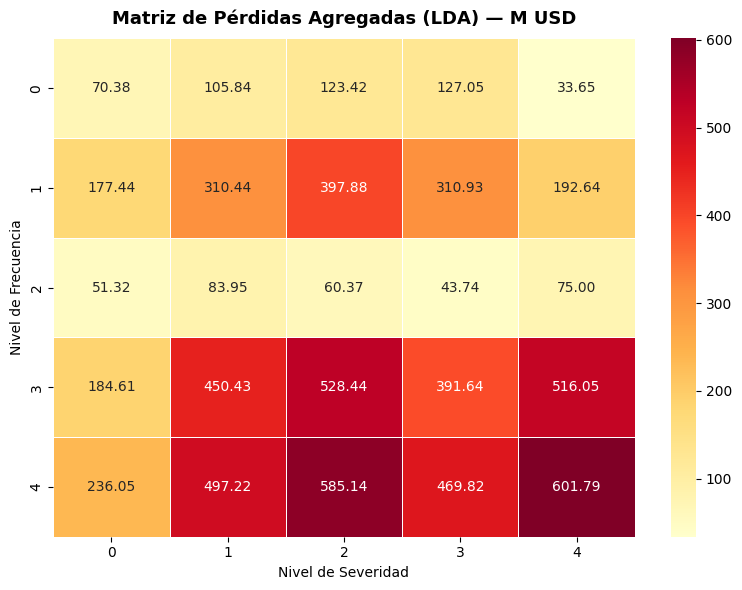

Referencia de índices de celda: fila=Nivel_F (0-4), columna=Nivel_S (0-4)


In [14]:
# Matriz de Pérdidas Agregadas (suma de LDA por celda)
MLDA = np.zeros((5, 5))
for k in range(len(Xf)):
    nf = df.iloc[k]['Nivel_F']
    nc = df.iloc[k]['Nivel_S']
    MLDA[nf, nc] += LDA[k]

fig, ax = plt.subplots(figsize=(8, 6))
hm = sns.heatmap(MLDA, annot=True, fmt='.2f', cmap='YlOrRd',
                 linewidths=0.5, ax=ax)
ax.set_title('Matriz de Pérdidas Agregadas (LDA) — M USD', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Nivel de Severidad')
ax.set_ylabel('Nivel de Frecuencia')
plt.tight_layout()
plt.savefig('matriz_lda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Referencia de índices de celda: fila=Nivel_F (0-4), columna=Nivel_S (0-4)')

In [18]:
def auditar_celda(nivel_frecuencia: int, nivel_severidad: int):
    assert 0 <= nivel_frecuencia <= 4, 'nivel_frecuencia debe ser entre 0 y 4'
    assert 0 <= nivel_severidad  <= 4, 'nivel_severidad debe ser entre 0 y 4'

    filtro = (df['Nivel_F'] == nivel_frecuencia) & (df['Nivel_S'] == nivel_severidad)
    resultado = df[filtro][['Fecha', 'Freq', 'Sev', 'LDA', 'Descripcion']].copy()
    resultado.columns = ['Fecha', 'Trans. Fallidas', 'Severidad (M USD)',
                         'Pérdida Agregada (M USD)', 'Descripción del Evento']
    resultado = resultado.reset_index(drop=True)
    resultado.index += 1

    print('=' * 70)
    print(f'  AUDITORÍA — Celda [{nivel_frecuencia}, {nivel_severidad}]')
    print(f'  Total de eventos en la celda : {len(resultado)}')
    print(f'  Pérdida total de la celda    : {MLDA[nivel_frecuencia, nivel_severidad]:.4f} M USD')
    print('=' * 70)

    if len(resultado) == 0:
        print('  ⚠ No hay eventos registrados en esta celda.')
    else:
        pd.set_option('display.max_colwidth', 80)
        display(resultado)

    return resultado

# Inspeccionamos cualquier celda de la matriz
FILA_AUDITORIA   = 4   # Nivel de Frecuencia a auditar  (0=Muy Bajo … 4=Muy Alto)
COLUMNA_AUDITORIA = 4  # Nivel de Severidad a auditar   (0=Muy Bajo … 4=Muy Alto)

eventos_auditados = auditar_celda(FILA_AUDITORIA, COLUMNA_AUDITORIA)

  AUDITORÍA — Celda [4, 4]
  Total de eventos en la celda : 9
  Pérdida total de la celda    : 601.7898 M USD


,Fecha,Trans. Fallidas,Severidad (M USD),Pérdida Agregada (M USD),Descripción del Evento
1,2009-01-04,6,1.0814,6.4884,"Errores en la interfaz de usuario, fallas en funcionalidades secundarias, pr..."
2,2009-01-05,7,1.2105,8.4735,"Errores en la interfaz de usuario, fallas en funcionalidades secundarias, pr..."
3,2009-01-08,8,12.4245,99.3960,"Caída total del sistema por más de 24 horas, pérdida masiva de datos de clie..."
4,2009-03-06,9,6.6729,60.0561,"Degradación severa del rendimiento por más de 12 horas, interrupción prolong..."
5,2009-08-07,9,9.1223,82.1007,"Caída total del sistema por más de 24 horas, pérdida masiva de datos de clie..."
6,2009-09-10,10,11.1083,111.0830,"Caída total del sistema por más de 24 horas, pérdida masiva de datos de clie..."
7,2011-02-03,9,9.0824,81.7416,"Degradación severa del rendimiento por más de 12 horas, interrupción prolong..."
8,2011-03-02,8,9.8843,79.0744,"Caída total del sistema por más de 24 horas, pérdida masiva de datos de clie..."
9,2011-03-04,9,8.1529,73.3761,"Degradación severa del rendimiento por más de 12 horas, interrupción prolong..."


In [20]:
resumen = []
for i in range(5):
    for j in range(5):
        filtro = (df['Nivel_F'] == i) & (df['Nivel_S'] == j)
        n_eventos = filtro.sum()
        if n_eventos > 0:
            resumen.append({
                'Celda [F,S]'         : f'[{i},{j}]',
                'N° Eventos'          : int(n_eventos),
                'Pérdida Total (M USD)': round(MLDA[i, j], 4),
                'Nivel Impacto'       : int(MI[i, j]),
                'Nivel Gestión (NG)'  : round(MG[i, j], 1),
            })

df_resumen = pd.DataFrame(resumen).sort_values('Pérdida Total (M USD)', ascending=False)
df_resumen = df_resumen.reset_index(drop=True)
df_resumen.index += 1

print('RESUMEN DE CELDAS CON EVENTOS — Ordenado por Pérdida Descendente')
display(df_resumen)

RESUMEN DE CELDAS CON EVENTOS — Ordenado por Pérdida Descendente


,"Celda [F,S]",N° Eventos,Pérdida Total (M USD),Nivel Impacto,Nivel Gestión (NG)
1,"[4,4]",9,601.7898,5,5
2,"[4,2]",22,585.1430,4,8
3,"[3,2]",33,528.4370,3,6
4,"[3,4]",9,516.0474,4,8
5,"[4,1]",38,497.2210,3,6
6,"[4,3]",12,469.8179,4,8
7,"[3,1]",49,450.4289,3,6
8,"[1,2]",31,397.8820,2,4
9,"[3,3]",12,391.6433,4,8
10,"[1,3]",15,310.9301,3,6


##**Análisis de Resultados**

La Pérdida Esperada Simple evidencia que, en promedio, los eventos tecnológicos generan una pérdida de 27.05 millones USD. Este valor representa una visión básica del costo promedio de materialización del riesgo sin considerar ponderaciones de criticidad o distribución de frecuencia.
La Pérdida Esperada Ponderada se ubica en 26.38 millones USD, mostrando una ligera reducción frente al promedio simple. Esto indica que, aunque existen eventos de alta severidad, la mayoría de ocurrencias se concentran en niveles intermedios de impacto.
Con la Matriz de Impacto, donde se asigna mayor relevancia a eventos de alta criticidad, la Pérdida Esperada Inherente aumenta a 27.79 millones USD, evidenciando que la exposición real del banco es superior cuando se analiza estratégicamente el peso de los eventos críticos.


El Operational Value at Risk (OpVaR) al 99.9%, que mide la pérdida máxima esperada bajo escenarios extremos, muestra una exposición inherente de 102.90 millones USD. Este valor es especialmente relevante porque refleja eventos de baja frecuencia pero alto impacto, como:
caída masiva de la app bancaria, fraudes tecnológicos coordinados o vulneraciones de ciberseguridad.

Los resultados muestran que la entidad financiera tiene una exposición significativa al riesgo operacional en canales electrónicos, especialmente en eventos críticos de naturaleza tecnológica. La mayor exposición económica está concentrada en eventos de alta severidad y se debe priorizar la intervención en las celdas superiores de la matriz de impacto. El banco debería enfocar sus recursos en prevención tecnológica, monitoreo en tiempo real y fortalecimiento de continuidad operativa, ya que ahí se encuentra la mayor oportunidad de reducción de pérdidas futuras.
